## Validações Estatísticas do BeamNG como Digital Twin (Circuito 4)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

#### 1.1 Simulado

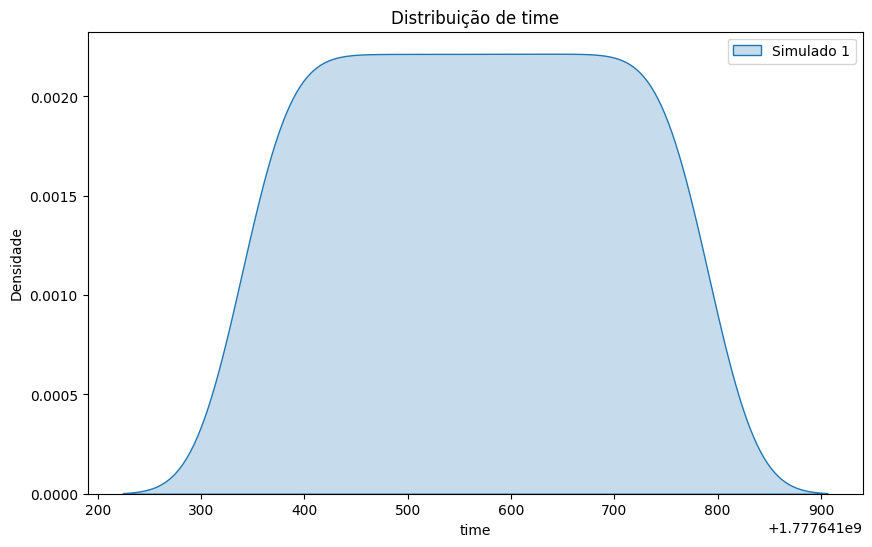

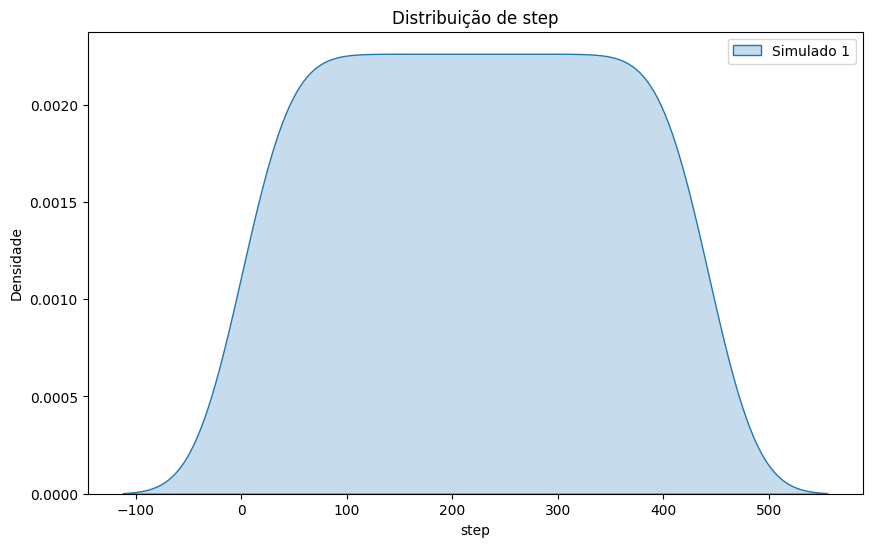

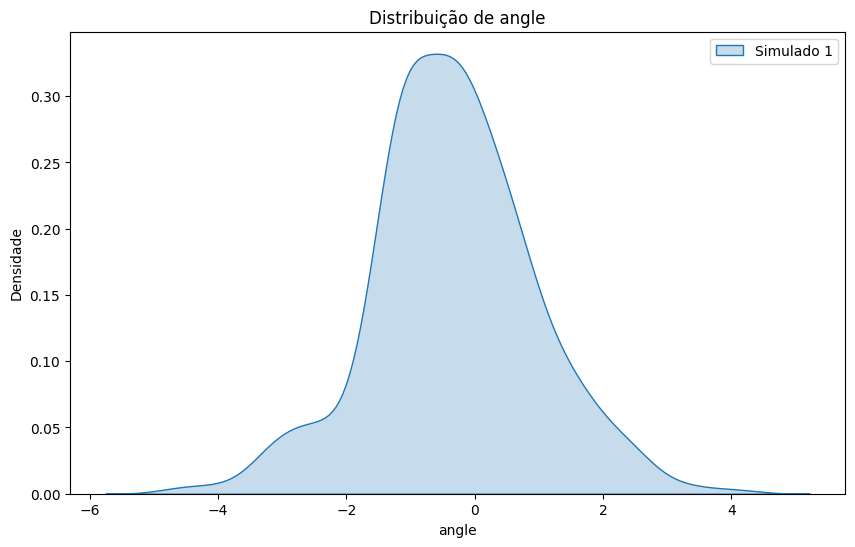

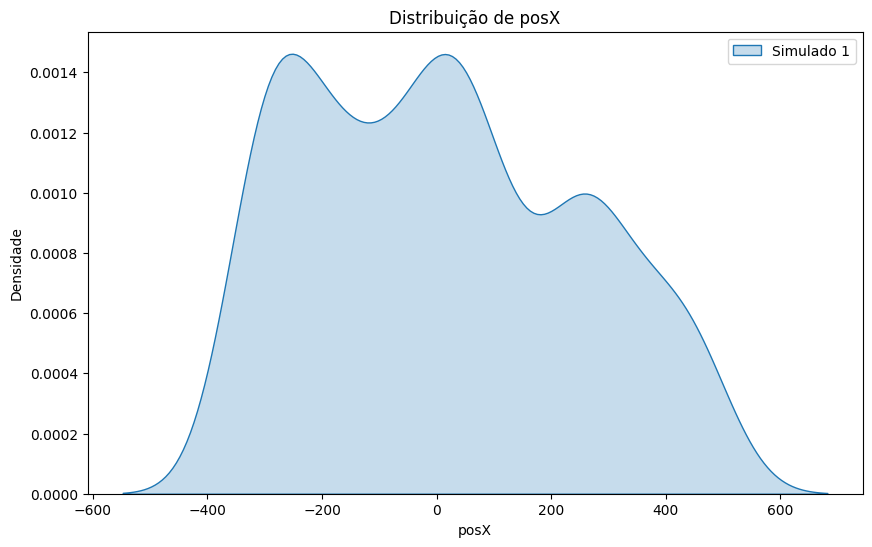

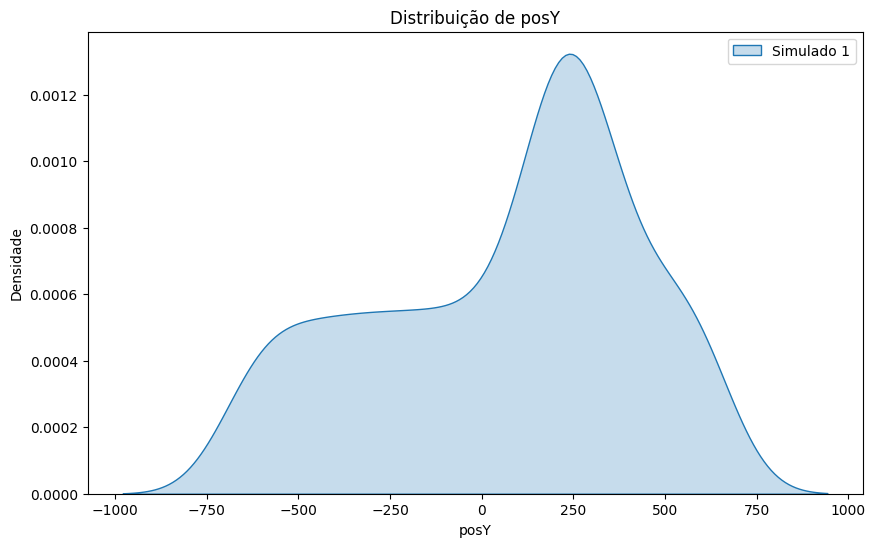

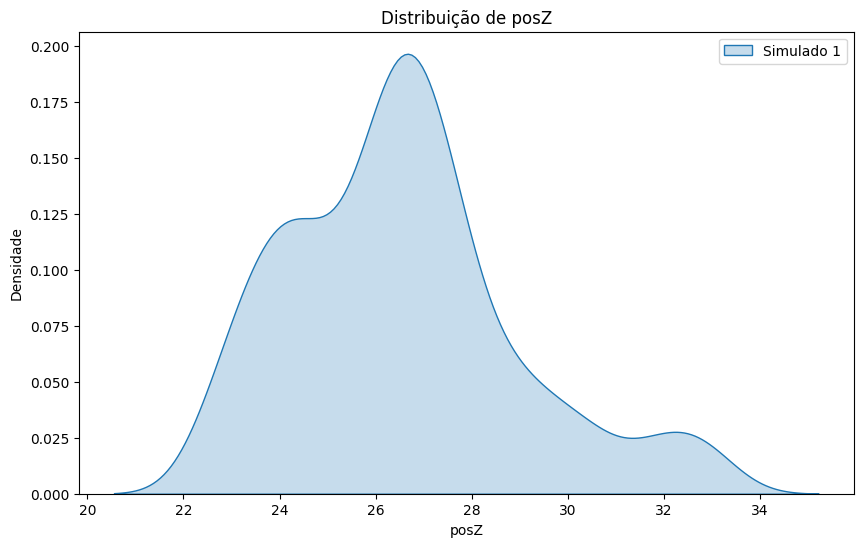

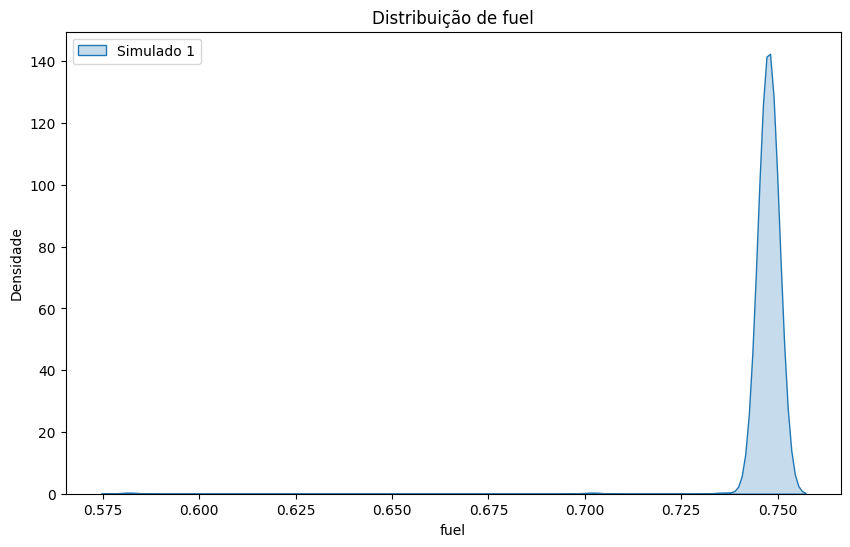

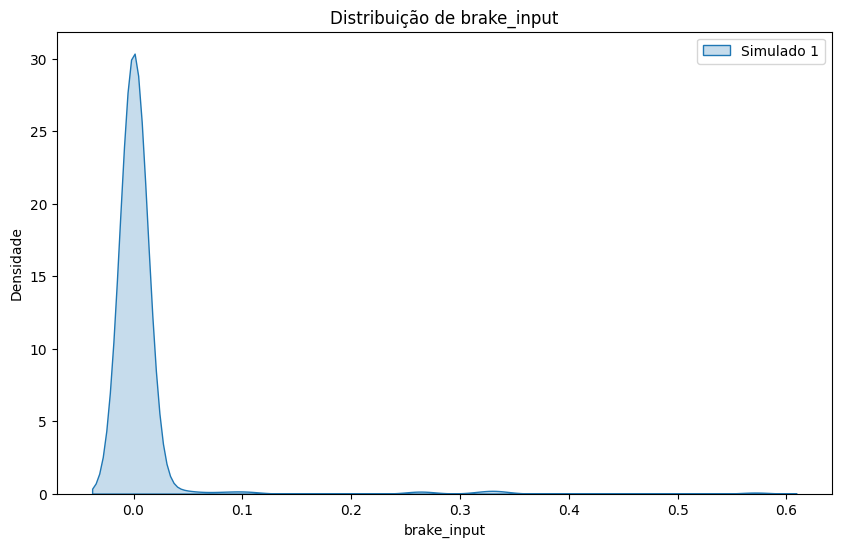

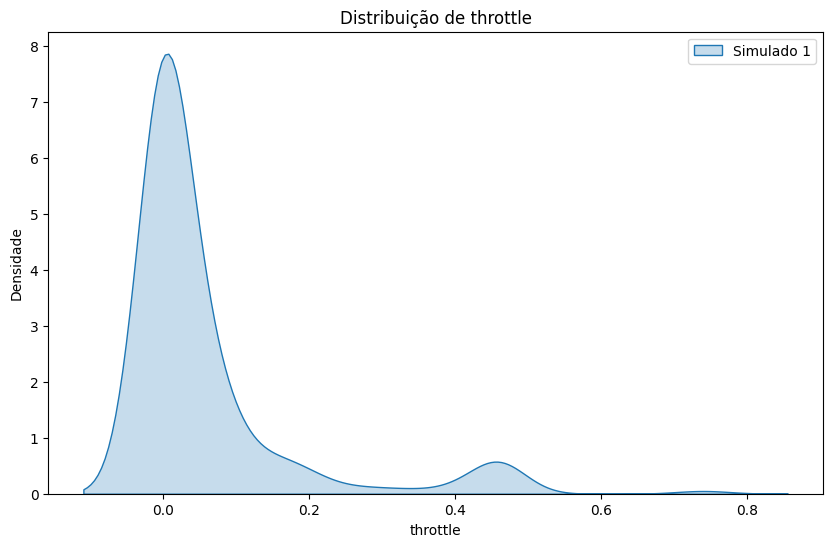

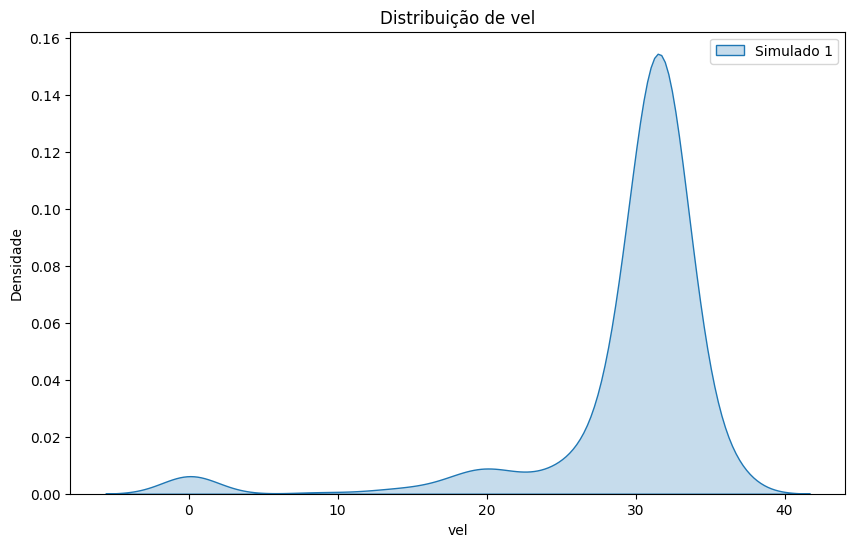

In [3]:
from os import listdir
import ast

simulados = []

for dir in listdir('circuito4/simulado_taxa_coleta_correta'):
    simulados.append(pd.read_csv(f'circuito4/simulado_taxa_coleta_correta/{dir}', sep=';'))

colluns = simulados[0].columns

# Convertendo a coluna de velocidade para km/h
for simulado in simulados:
    simulado['vel'] = simulado['vel'].apply(
        lambda x: np.sqrt(sum(i**2 for i in ast.literal_eval(x))) * 3.6
    )

    # diferença entre pontos consecutivos
    dx = simulado["posX"].diff()
    dy = simulado["posY"].diff()
    dz = simulado["posZ"].diff()

    # distância entre cada passo (em metros, provavelmente)
    simulado["dist_step"] = np.sqrt(dx**2 + dy**2 + dz**2)

    # acumulado
    simulado["dist_acumulada_m"] = simulado["dist_step"].cumsum()

    # converter pra km
    simulado["dist_acumulada_km"] = simulado["dist_acumulada_m"] / 1000

for collun in colluns:
    plt.figure(figsize=(10, 6))
    for i, simulado in enumerate(simulados):
        sns.kdeplot(simulado[collun], label=f'Simulado {i+1}', fill=True)
    plt.title(f'Distribuição de {collun}')
    plt.xlabel(collun)
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

#### 1.2 Real

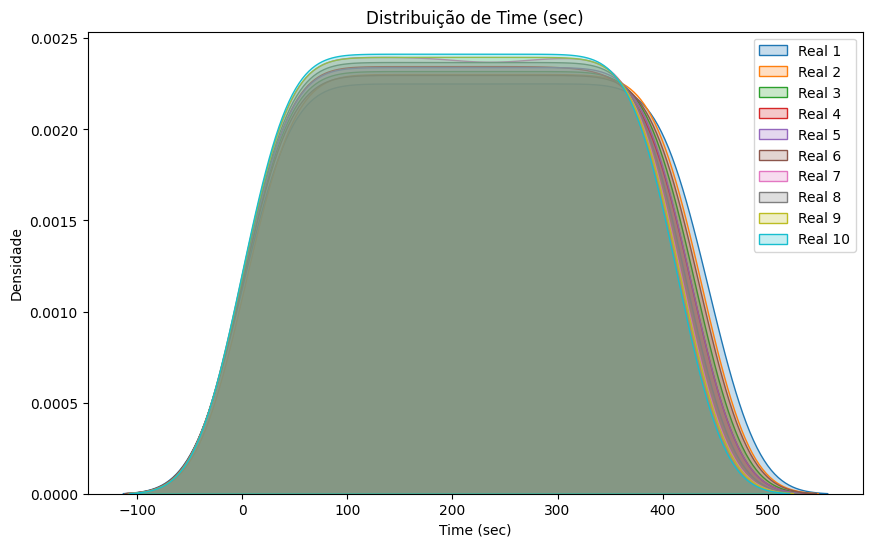

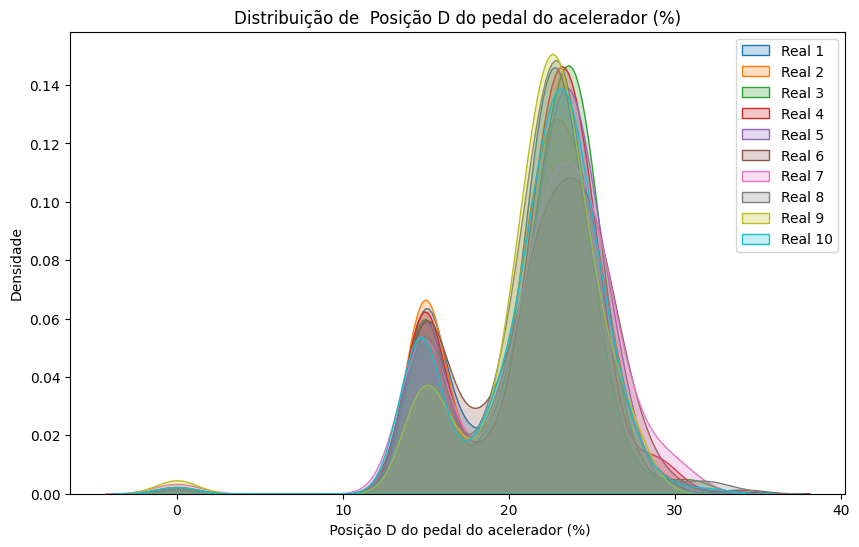

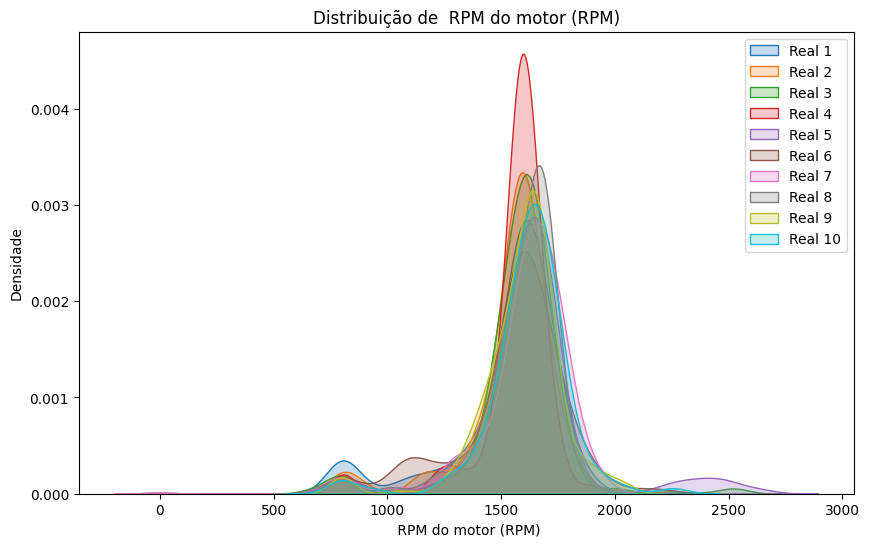

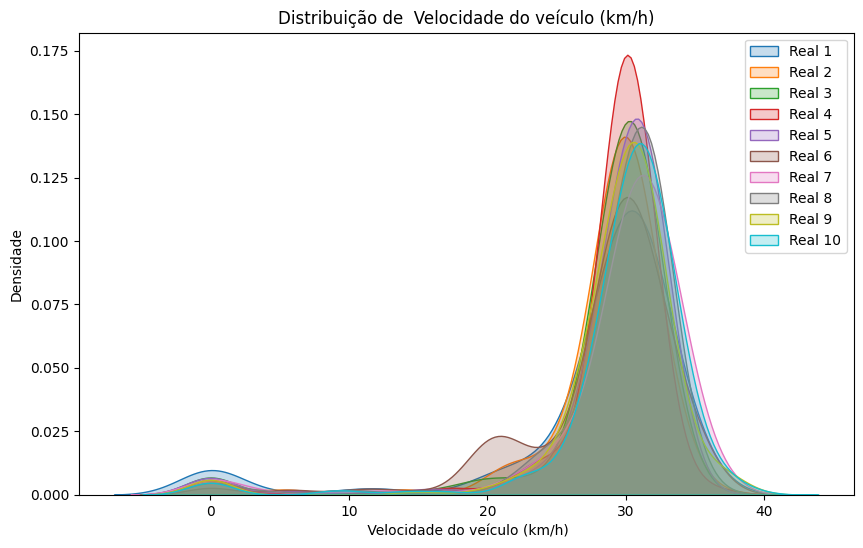

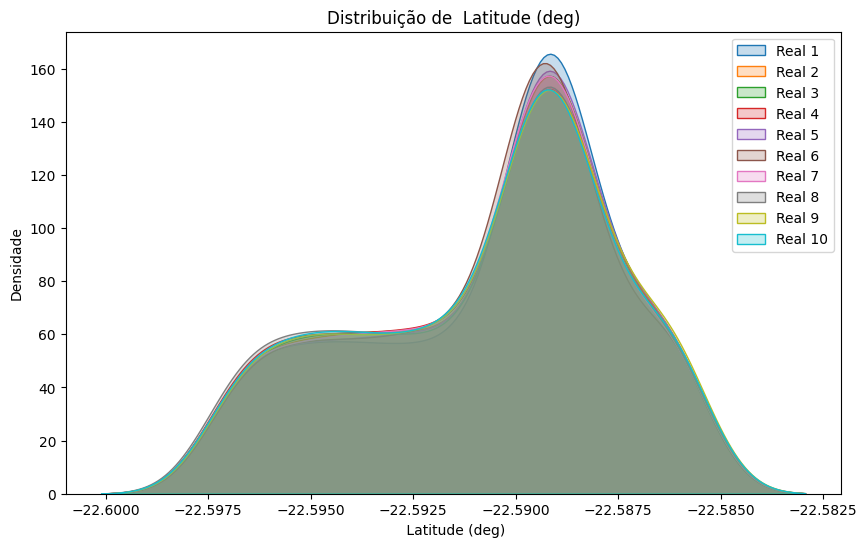

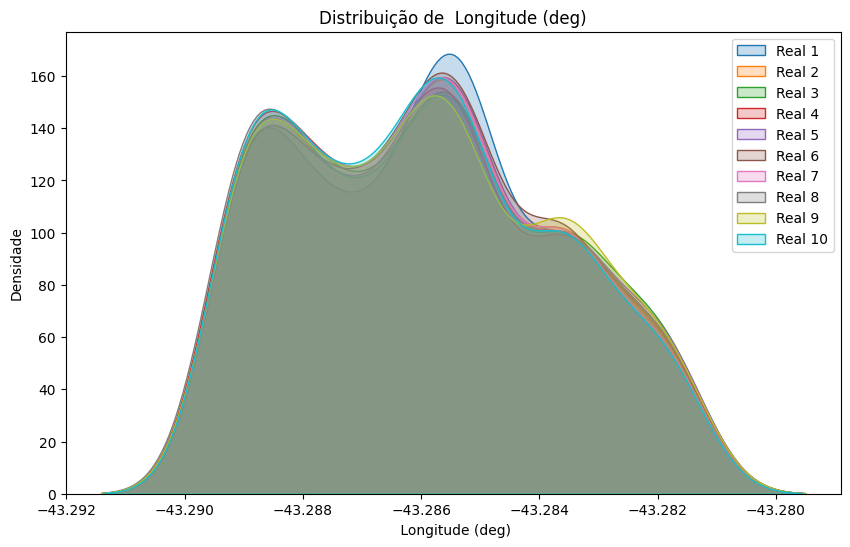

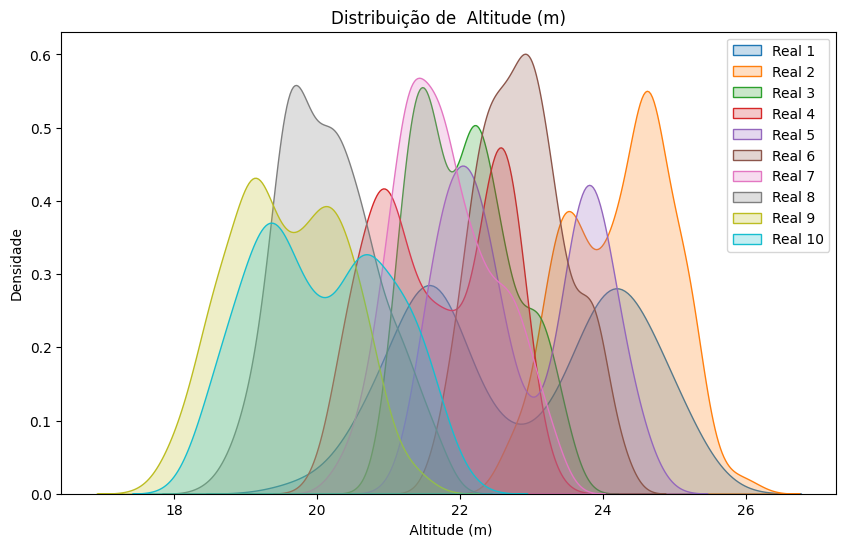

In [4]:
from os import listdir

reais = []

for file in listdir('circuito4/real'):
    reais.append(pd.read_csv(f'./circuito4/real/{file}', sep=','))

colluns = ['Time (sec)', ' Posição D do pedal do acelerador (%)', ' RPM do motor (RPM)', ' Velocidade do veículo (km/h)', ' Latitude (deg)', ' Longitude (deg)', ' Altitude (m)']

for collun in colluns:
    plt.figure(figsize=(10, 6))
    for i, real in enumerate(reais):
        sns.kdeplot(real[collun], label=f'Real {i+1}', fill=True)
    plt.title(f'Distribuição de {collun}')
    plt.xlabel(collun)
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

#### 1.3 Comparando o minimapa dos trajetos entre real e simulado

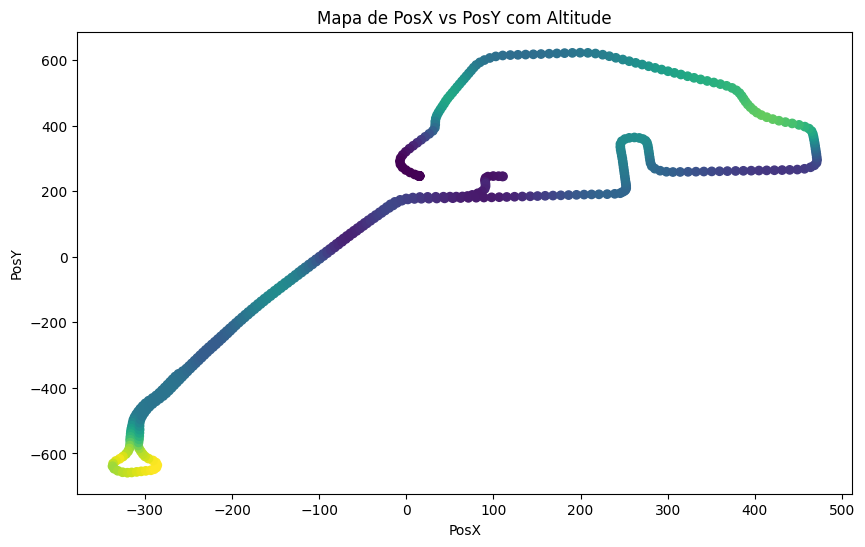

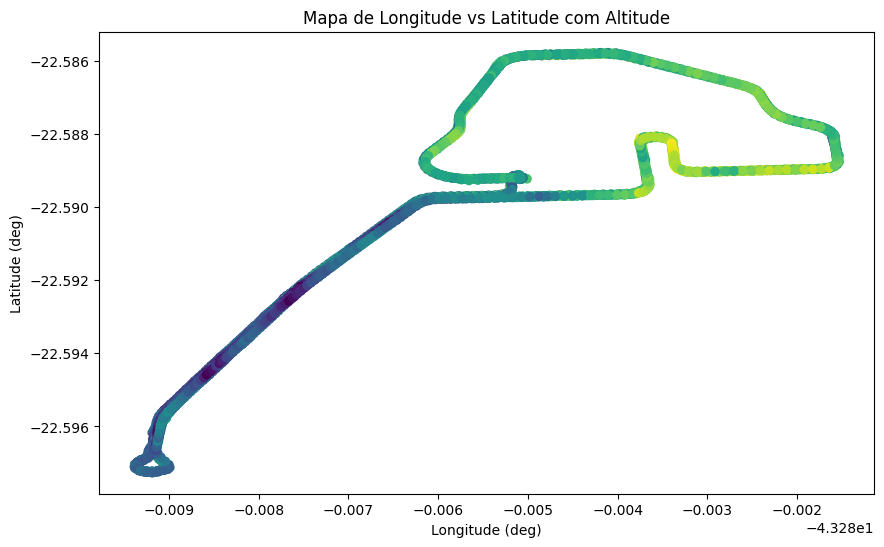

In [5]:
# Criando um mapa com posX, posY e posZ do beamng
plt.figure(figsize=(10, 6))
for simulado in simulados:
    plt.scatter(simulado['posX'], simulado['posY'], c=simulado['posZ'], cmap='viridis')
    plt.title('Mapa de PosX vs PosY com Altitude')
    plt.xlabel('PosX')
    plt.ylabel('PosY')
plt.show()

# Criando um mapa com Latitude, Longitude e Altitude dos dados reais
plt.figure(figsize=(10, 6))
for real in reais:
    plt.scatter(real[' Longitude (deg)'], real[' Latitude (deg)'], c=real[' Altitude (m)'], cmap='viridis')
    plt.title('Mapa de Longitude vs Latitude com Altitude')
    plt.xlabel('Longitude (deg)')
    plt.ylabel('Latitude (deg)')
plt.show()

### 2. Análises Estatísticas

In [6]:
# Fazendo a associação entre as colunas dos dados simulados e reais
colunas = {'time': 'Time (sec)', 'throttle': ' Posição D do pedal do acelerador (%)', 'vel': ' Velocidade do veículo (km/h)', 'posY': ' Latitude (deg)', 'posX': ' Longitude (deg)', 'posZ': ' Altitude (m)', 'fuel': ' Entrada do nível de combustível (%)', 'dist_acumulada_km': ' Distância da viagem (km)'}

In [7]:
# Renomeando as colunas dos dados simulados para facilitar a comparação
for simulado in simulados:
    simulado.rename(columns=colunas, inplace=True)

colunas = colunas.values()  # Pegando apenas os nomes das colunas reais para comparação

Antes de operar as análises estatísticas, deve-se realizar a normalização dos dados de ambos os datasets, de forma a desprezar as unidades de medida

In [8]:
df_all = pd.concat(
    [df[colunas] for df in reais + simulados],
    ignore_index=True
)

mean_vals = df_all.mean()
std_vals  = df_all.std()

cols_sem_tempo = [c for c in colunas if c != 'Time (sec)']

def normalizar(df):
    out = df.copy()
    out[cols_sem_tempo] = (df[cols_sem_tempo] - mean_vals[cols_sem_tempo]) / std_vals[cols_sem_tempo]
    return out

dfs_real_norm = [normalizar(df) for df in reais]
dfs_sim_norm  = [normalizar(df) for df in simulados]

#### 2.1 Comparação entre médias

In [9]:
from scipy.stats import ttest_ind

simulado = dfs_sim_norm[0]

for coluna in colunas:

    print(f'Comparando a coluna {coluna} entre os dados simulados e reais:\n')

    for i, real in enumerate(dfs_real_norm):
        stat, p = ttest_ind(simulado[coluna], real[coluna], equal_var=False)
        if p > 0.05:
            print(f'    Dataset {i+1} \033[92mPassou: p-value = {p:.4f}\n\033[0m')
        else:
            print(f'    Dataset {i+1} \033[91mFalhou: p-value = {p:.4f}\n\033[0m')
        

Comparando a coluna Time (sec) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 0.0000

    Dataset 2 Falhou: p-value = 0.0000

    Dataset 3 Falhou: p-value = 0.0000

    Dataset 4 Falhou: p-value = 0.0000

    Dataset 5 Falhou: p-value = 0.0000

    Dataset 6 Falhou: p-value = 0.0000

    Dataset 7 Falhou: p-value = 0.0000

    Dataset 8 Falhou: p-value = 0.0000

    Dataset 9 Falhou: p-value = 0.0000

    Dataset 10 Falhou: p-value = 0.0000

Comparando a coluna  Posição D do pedal do acelerador (%) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 0.0000

    Dataset 2 Falhou: p-value = 0.0000

    Dataset 3 Falhou: p-value = 0.0000

    Dataset 4 Falhou: p-value = 0.0000

    Dataset 5 Falhou: p-value = 0.0000

    Dataset 6 Falhou: p-value = 0.0000

    Dataset 7 Falhou: p-value = 0.0000

    Dataset 8 Falhou: p-value = 0.0000

    Dataset 9 Falhou: p-value = 0.0000

    Dataset 10 Falhou: p-value = 0.0000

Comparando a coluna  Velocidade do veíc

#### 2.2 Teste TOST para verificar semelhança

In [10]:
from statsmodels.stats.weightstats import ttost_ind

simulado = dfs_sim_norm[0]

for coluna in colunas:

    print(f'Comparando a coluna {coluna} entre os dados simulados e reais:\n')

    for i, real in enumerate(dfs_real_norm):
        p, g1, g2 = ttost_ind(simulado[coluna], real[coluna], low=-0.5, upp=0.5, usevar='unequal')
        if p < 0.05:
            print(f'    Dataset {i+1} \033[92mPassou: p-value = {p:.4f}\n\033[0m')
        else:
            print(f'    Dataset {i+1} \033[91mFalhou: p-value = {p:.4f}\n\033[0m')

Comparando a coluna Time (sec) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 1.0000

    Dataset 2 Falhou: p-value = 1.0000

    Dataset 3 Falhou: p-value = 1.0000

    Dataset 4 Falhou: p-value = 1.0000

    Dataset 5 Falhou: p-value = 1.0000

    Dataset 6 Falhou: p-value = 1.0000

    Dataset 7 Falhou: p-value = 1.0000

    Dataset 8 Falhou: p-value = 1.0000

    Dataset 9 Falhou: p-value = 1.0000

    Dataset 10 Falhou: p-value = 1.0000

Comparando a coluna  Posição D do pedal do acelerador (%) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 1.0000

    Dataset 2 Falhou: p-value = 1.0000

    Dataset 3 Falhou: p-value = 1.0000

    Dataset 4 Falhou: p-value = 1.0000

    Dataset 5 Falhou: p-value = 1.0000

    Dataset 6 Falhou: p-value = 1.0000

    Dataset 7 Falhou: p-value = 1.0000

    Dataset 8 Falhou: p-value = 1.0000

    Dataset 9 Falhou: p-value = 1.0000

    Dataset 10 Falhou: p-value = 1.0000

Comparando a coluna  Velocidade do veíc

### 3. Tratando como séries temporais

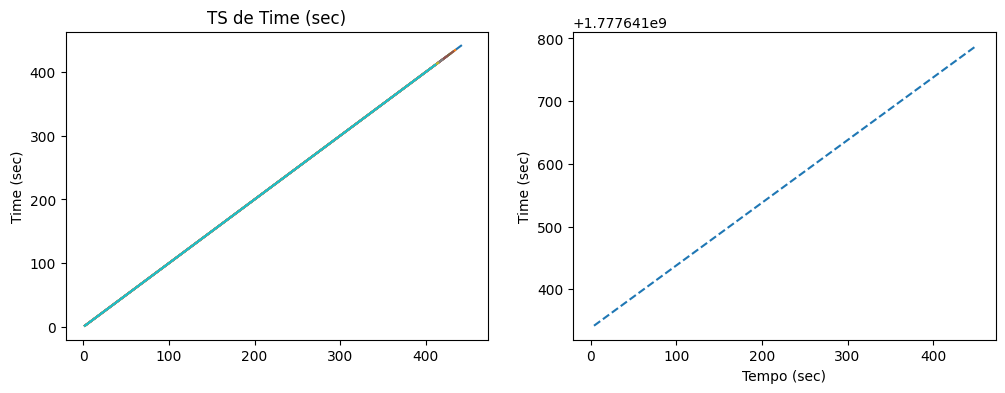

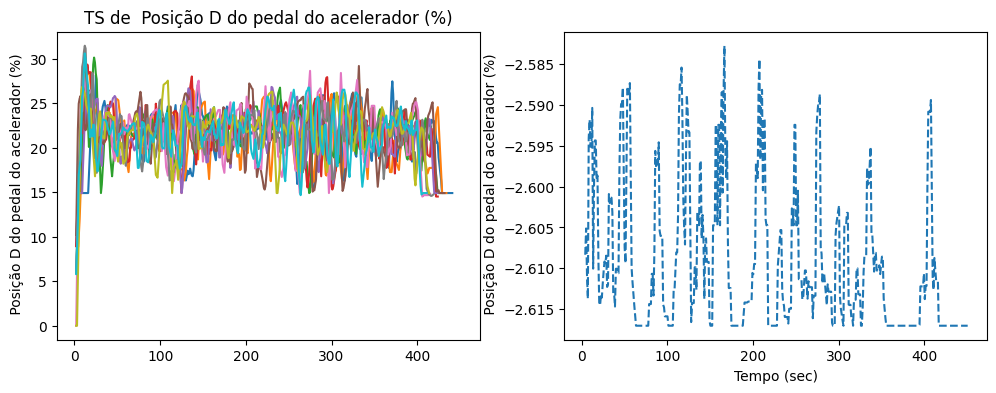

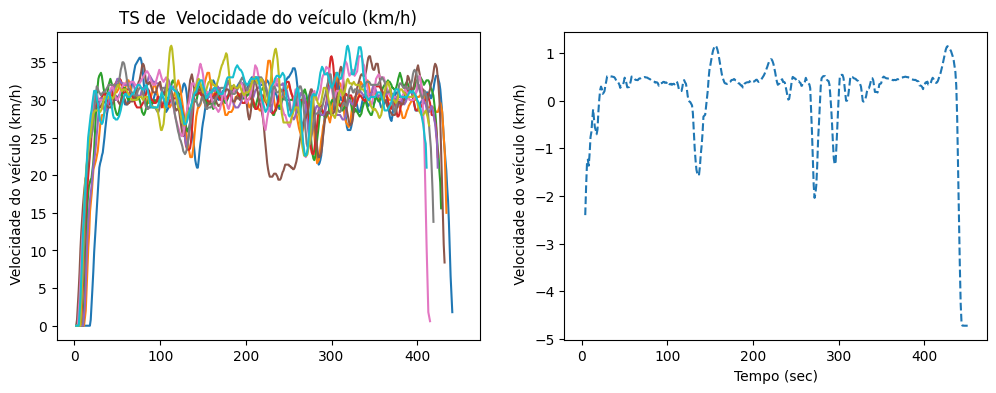

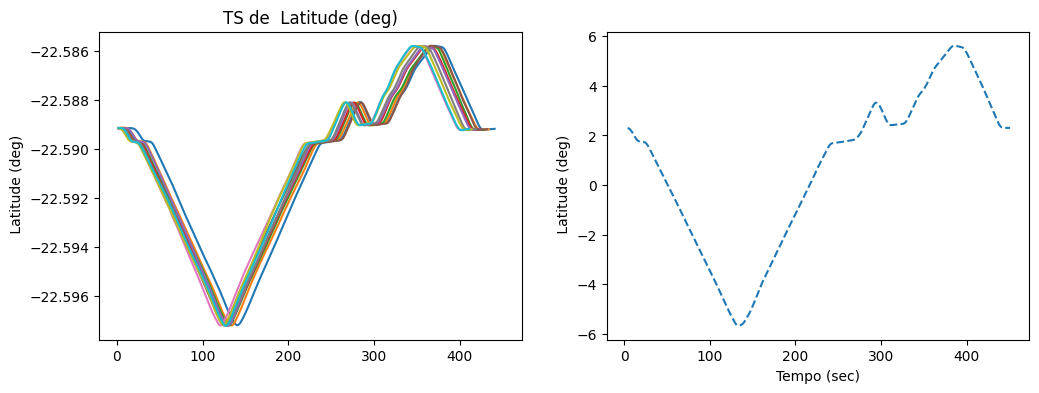

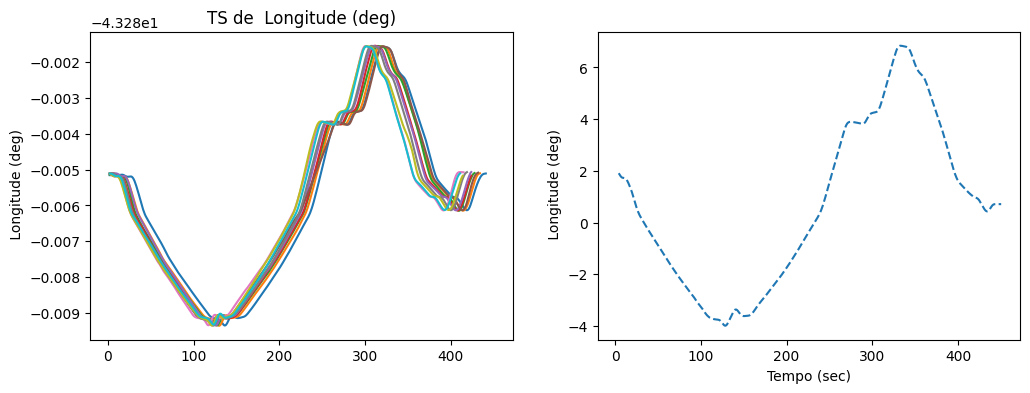

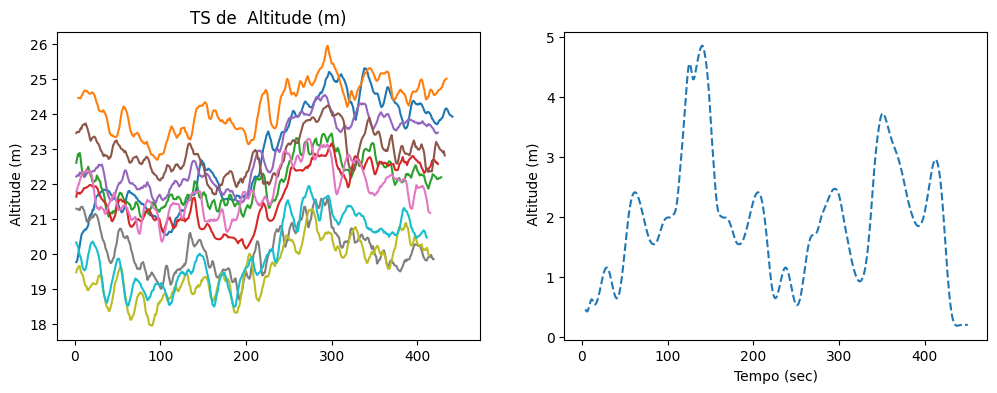

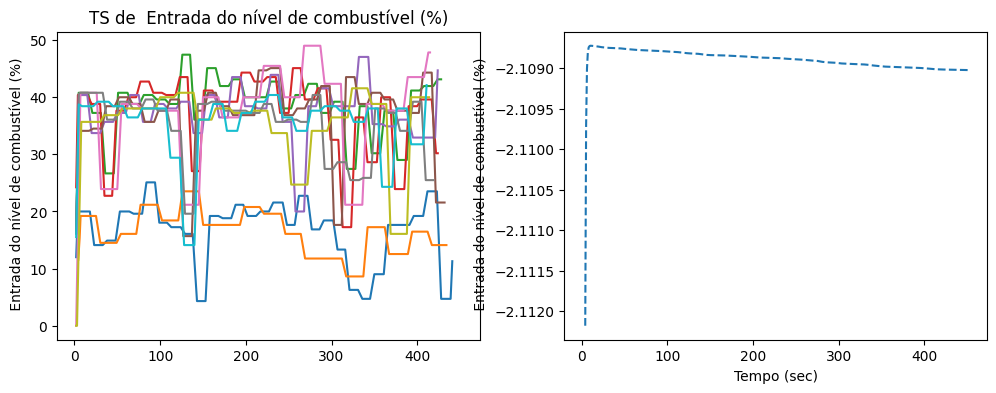

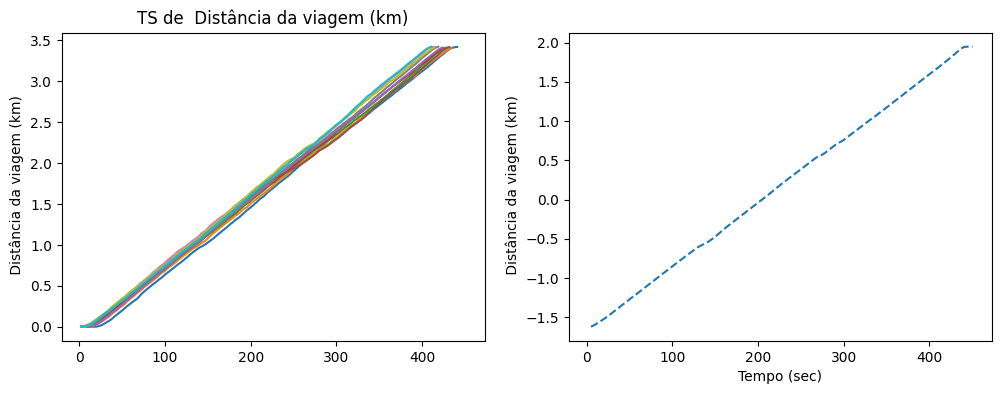

In [11]:
simulado['time_relativo'] = simulado['Time (sec)'] - simulado['Time (sec)'].iloc[0]

# Aplicando filtro de média móvel para suavizar as séries temporais reais e simuladas
window_size = 5
simulado_smooth = simulado.copy()
reais_smooth = [real.copy() for real in reais]

for collun in colunas:
    simulado_smooth[collun] = simulado[collun].rolling(window=window_size).mean()

for i, real in enumerate(reais):
    for collun in colunas:
        reais_smooth[i][collun] = real[collun].rolling(window=window_size).mean()

for collun in colunas:
    
    # Utilizando subplots de 2 col e 1 linha, uma com os reais e outra com o simulado
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for i, real_smooth in enumerate(reais_smooth):
        axs[0].plot(real_smooth['Time (sec)'], real_smooth[collun], label=f'Real {i+1}')
        axs[0].set_title(f'TS de {collun}')
        axs[0].set_ylabel(collun)

    axs[1].set_xlabel('Tempo (sec)')
    axs[1].set_ylabel(collun)
    axs[1].plot(simulado_smooth['time_relativo'], simulado_smooth[collun], label='Simulado', linestyle='--')
    plt.show()

#### Comparando uma instância de cada categoria de trajeto

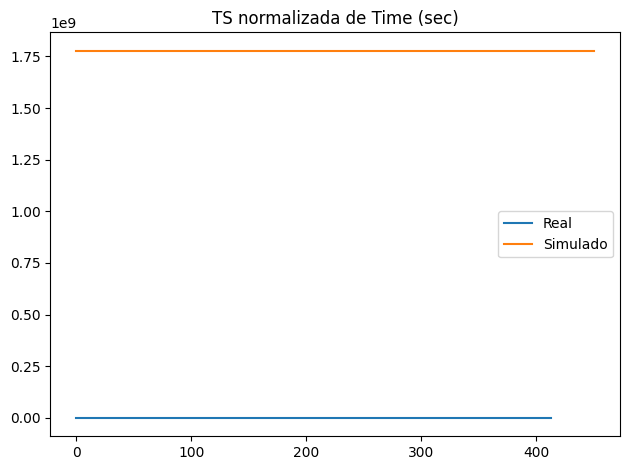

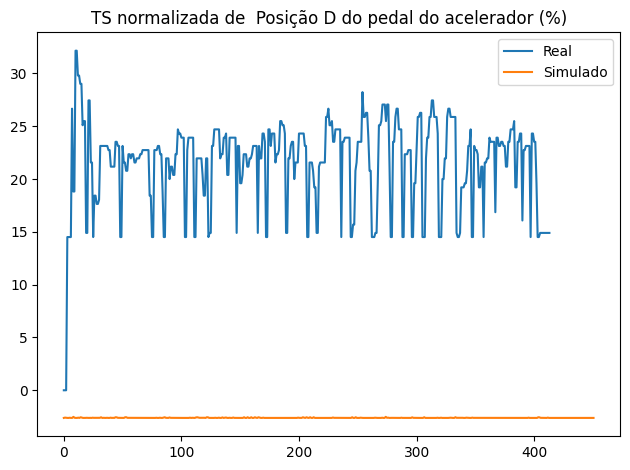

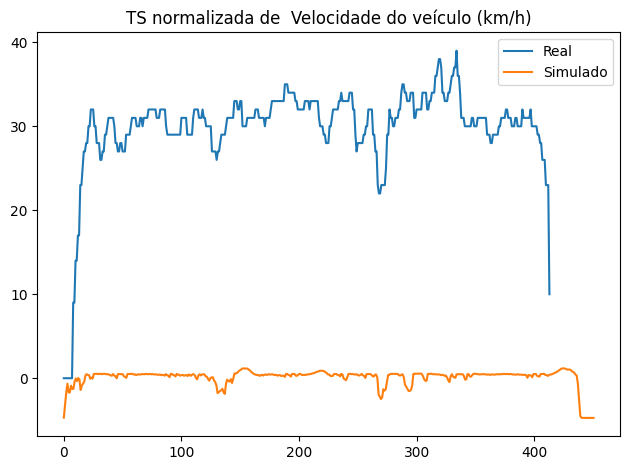

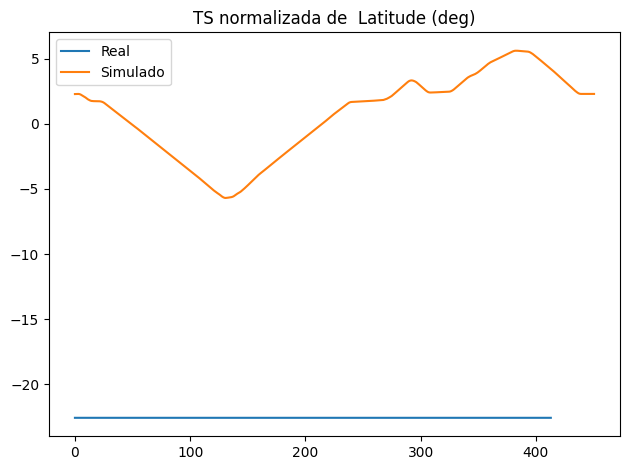

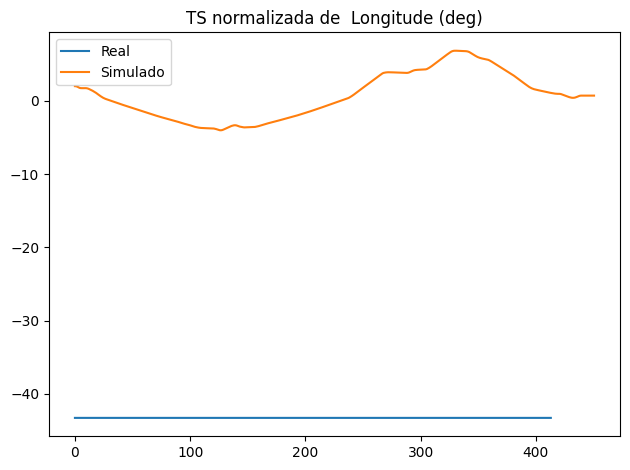

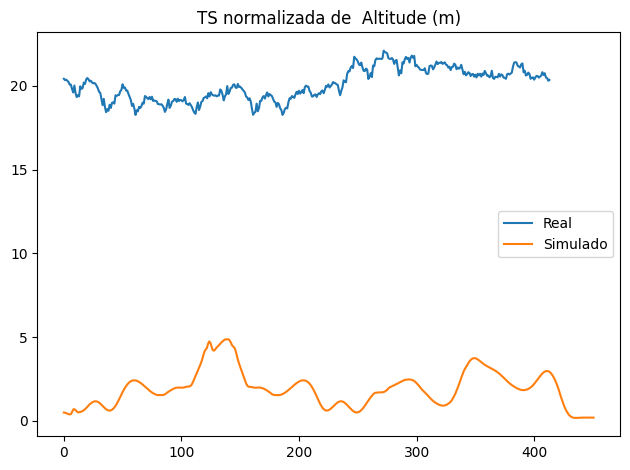

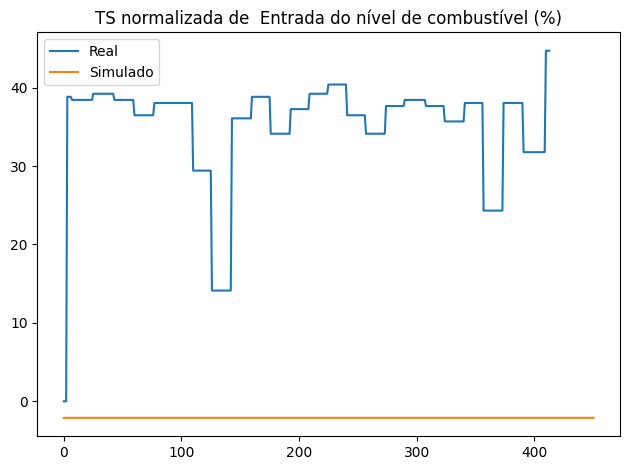

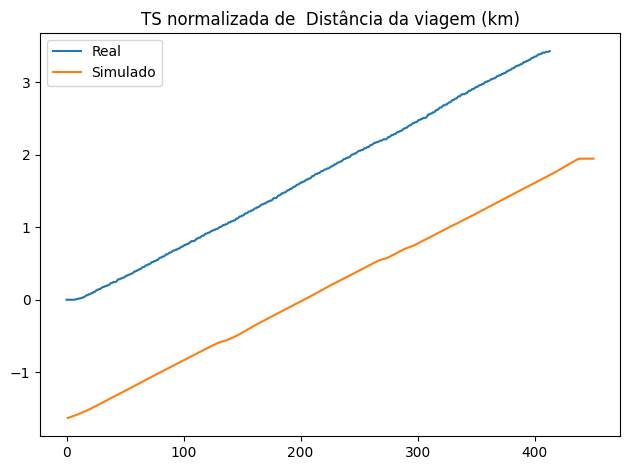

In [12]:
for collun in colunas:

    plt.plot(real['Time (sec)'],real[collun], label='Real')
    plt.plot(simulado['time_relativo'], simulado[collun], label='Simulado')

    plt.title(f'TS normalizada de {collun}')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Correlação de Pearson utilizando janelas deslizantes

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

for coluna in colunas:

    x = pd.to_numeric(real[coluna], errors='coerce').dropna().values
    y = pd.to_numeric(simulado[coluna], errors='coerce').dropna().values

    # Garantir mesmo tamanho
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]

    # Evitar vetor constante
    if np.std(x) == 0 or np.std(y) == 0:
        print(f'\n{coluna}')
        print("Não foi possível calcular Pearson (desvio padrão zero).")
        continue

    r, p = pearsonr(x, y)

    print(f'\n{coluna}')
    print(f'Pearson global: {r:.3f}')
    print(f'p-value: {p:.6f}')


Time (sec)
Pearson global: 1.000
p-value: 0.000000

 Posição D do pedal do acelerador (%)
Pearson global: 0.033
p-value: 0.498208

 Velocidade do veículo (km/h)
Pearson global: 0.486
p-value: 0.000000

 Latitude (deg)
Pearson global: 0.960
p-value: 0.000000

 Longitude (deg)
Pearson global: 0.933
p-value: 0.000000

 Altitude (m)
Pearson global: -0.043
p-value: 0.388260

 Entrada do nível de combustível (%)
Pearson global: 0.357
p-value: 0.000000

 Distância da viagem (km)
Pearson global: 1.000
p-value: 0.000000


### Avaliação dos efeitos do parâmetro de agressividade

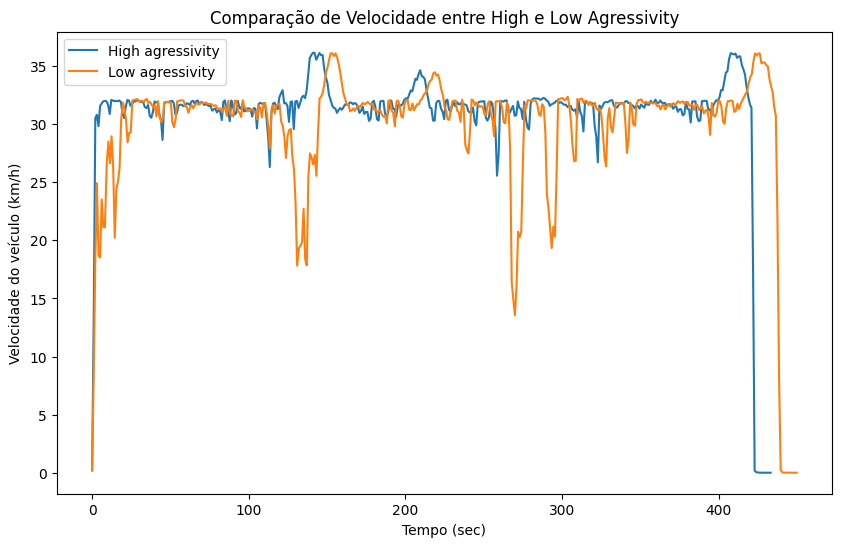

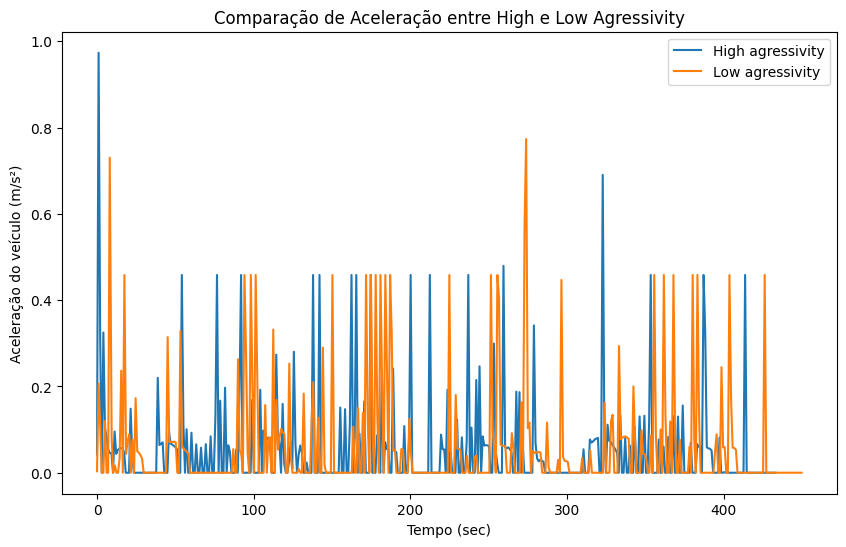

In [22]:
df_high_agressivity = pd.read_csv('./circuito4/testando_agressivity/high_aggr.csv', sep=';')
df_low_agressivity = pd.read_csv('./circuito4/testando_agressivity/low_aggr.csv', sep=';')

df_high_agressivity['time_relativo'] = df_high_agressivity['time'] - df_high_agressivity['time'].iloc[0]
df_low_agressivity['time_relativo'] = df_low_agressivity['time'] - df_low_agressivity['time'].iloc[0]

df_high_agressivity['vel'] = df_high_agressivity['vel'].apply(
        lambda x: np.sqrt(sum(i**2 for i in ast.literal_eval(x))) * 3.6
    )
df_low_agressivity['vel'] = df_low_agressivity['vel'].apply(
        lambda x: np.sqrt(sum(i**2 for i in ast.literal_eval
(x))) * 3.6
    )

# Comparando os TS de velocidade dos dois datasets
plt.figure(figsize=(10, 6))
plt.plot(df_high_agressivity['time_relativo'], df_high_agressivity['vel'], label='High agressivity')
plt.plot(df_low_agressivity['time_relativo'], df_low_agressivity['vel'], label='Low agressivity')
plt.title('Comparação de Velocidade entre High e Low Agressivity')
plt.xlabel('Tempo (sec)')
plt.ylabel('Velocidade do veículo (km/h)')
plt.legend()
plt.show()

# O mesmo para a aceleração
plt.figure(figsize=(10, 6))
plt.plot(df_high_agressivity['time_relativo'], df_high_agressivity['throttle'], label='High agressivity')
plt.plot(df_low_agressivity['time_relativo'], df_low_agressivity['throttle'], label='Low agressivity')
plt.title('Comparação de Aceleração entre High e Low Agressivity')
plt.xlabel('Tempo (sec)')
plt.ylabel('Aceleração do veículo (m/s²)')
plt.legend()
plt.show()